<a href="https://colab.research.google.com/github/FurqanAlyy/AI-ML-NIAI/blob/main/plate_recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [115]:
!git clone https://github.com/mhdatheek136/P-LPCD.git

fatal: destination path 'P-LPCD' already exists and is not an empty directory.


In [116]:
# !find P-LPCD -maxdepth 3 -type f | head -100
!ls P-LPCD

dataset_info  PR-LPCD  README.md   synthetic_generator
P-LPCD	      PS-LPCD  ReadMe.txt  test_videos


In [118]:
!ls -lh

total 1.2G
drwxr-xr-x 9 root root 4.0K Sep 20 14:04 P-LPCD
-rw-r--r-- 1 root root 1.2G Sep 20 12:22 P-LPCD.zip
drwxr-xr-x 1 root root 4.0K Sep 16 13:26 sample_data


In [119]:
!unzip -l P-LPCD.zip | head -50

Archive:  P-LPCD.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
        0  2025-09-23 08:05   P-LPCD/
        0  2025-09-23 08:10   P-LPCD/dataset_info/
     6244  2025-09-23 07:37   P-LPCD/dataset_info/class_instance_counts_PR-LPCD.xlsx
     6295  2025-09-23 07:37   P-LPCD/dataset_info/class_instance_counts_PS-LPCD.xlsx
    47854  2025-09-06 09:38   P-LPCD/dataset_info/class_instance_distribution_PR-LPCD.png
    67253  2025-09-06 09:37   P-LPCD/dataset_info/class_instance_distribution_PS-LPCD.png
   174647  2025-01-31 13:49   P-LPCD/dataset_info/lp_templates.png
  1286587  2025-09-02 19:12   P-LPCD/dataset_info/lp_variations.png
        0  2025-09-23 08:10   P-LPCD/dataset_info/ReadMe.txt
        0  2025-09-23 07:33   P-LPCD/PR-LPCD/
        0  2025-09-15 11:29   P-LPCD/PR-LPCD/images/
        0  2025-09-15 11:29   P-LPCD/PR-LPCD/images/train/
    20869  2025-07-24 06:33   P-LPCD/PR-LPCD/images/train/lp_0001.jpg
    14579  2025-07-24 06:33   P-LPCD/PR-LPCD/i

In [120]:
!unzip -l P-LPCD.zip | grep "PR-LPCD" | grep -E "\.txt$" | head -20

      349  2025-07-30 18:57   P-LPCD/PR-LPCD/labels/train/lp_0001.txt
      349  2025-07-30 18:57   P-LPCD/PR-LPCD/labels/train/lp_0002.txt
      350  2025-07-30 18:57   P-LPCD/PR-LPCD/labels/train/lp_0004.txt
      349  2025-07-30 18:57   P-LPCD/PR-LPCD/labels/train/lp_0005.txt
      350  2025-07-30 18:57   P-LPCD/PR-LPCD/labels/train/lp_0006.txt
      349  2025-07-30 18:57   P-LPCD/PR-LPCD/labels/train/lp_0008.txt
      349  2025-07-30 18:57   P-LPCD/PR-LPCD/labels/train/lp_0009.txt
      349  2025-07-30 18:57   P-LPCD/PR-LPCD/labels/train/lp_0010.txt
      427  2025-07-30 18:57   P-LPCD/PR-LPCD/labels/train/lp_0011.txt
      349  2025-07-30 18:57   P-LPCD/PR-LPCD/labels/train/lp_0012.txt
      311  2025-07-30 18:57   P-LPCD/PR-LPCD/labels/train/lp_0013.txt
      272  2025-07-30 18:57   P-LPCD/PR-LPCD/labels/train/lp_0014.txt
      272  2025-07-30 18:57   P-LPCD/PR-LPCD/labels/train/lp_0017.txt
      272  2025-07-30 18:57   P-LPCD/PR-LPCD/labels/train/lp_0018.txt
      349  2025-07-3

In [121]:
!find P-LPCD/PR-LPCD -type f | head -20

P-LPCD/PR-LPCD/ReadMe.txt
P-LPCD/PR-LPCD/labels/val/lp_0581.txt
P-LPCD/PR-LPCD/labels/val/lp_0003.txt
P-LPCD/PR-LPCD/labels/val/lp_0349.txt
P-LPCD/PR-LPCD/labels/val/lp_0184.txt
P-LPCD/PR-LPCD/labels/val/lp_0501.txt
P-LPCD/PR-LPCD/labels/val/lp_0623.txt
P-LPCD/PR-LPCD/labels/val/lp_0533.txt
P-LPCD/PR-LPCD/labels/val/lp_0025.txt
P-LPCD/PR-LPCD/labels/val/lp_0186.txt
P-LPCD/PR-LPCD/labels/val/lp_0234.txt
P-LPCD/PR-LPCD/labels/val/lp_0159.txt
P-LPCD/PR-LPCD/labels/val/lp_0236.txt
P-LPCD/PR-LPCD/labels/val/lp_0299.txt
P-LPCD/PR-LPCD/labels/val/lp_0463.txt
P-LPCD/PR-LPCD/labels/val/lp_0641.txt
P-LPCD/PR-LPCD/labels/val/lp_0424.txt
P-LPCD/PR-LPCD/labels/val/lp_0633.txt
P-LPCD/PR-LPCD/labels/val/lp_0231.txt
P-LPCD/PR-LPCD/labels/val/lp_0344.txt


In [122]:
!find P-LPCD/PR-LPCD/images -type f | wc -l
!find P-LPCD/PR-LPCD/labels -type f | wc -l

650
650


In [123]:
import os

for split in ["train", "val"]:
    image_dir = f"P-LPCD/PR-LPCD/images/{split}"
    label_dir = f"P-LPCD/PR-LPCD/labels/{split}"

    images = [f for f in os.listdir(image_dir) if f.endswith(".jpg")]
    labels = [f for f in os.listdir(label_dir) if f.endswith(".txt")]

    print(f"{split}:")
    print("  Images:", len(images))
    print("  Labels:", len(labels))

train:
  Images: 500
  Labels: 500
val:
  Images: 150
  Labels: 150


In [124]:
!cat P-LPCD/PR-LPCD/labels/train/lp_0001.txt

27 0.851150 0.265750 0.070740 0.170167
34 0.372360 0.694208 0.122520 0.239250
3 0.652520 0.343604 0.124040 0.229125
11 0.397950 0.430604 0.124540 0.244667
4 0.522430 0.393052 0.119140 0.233188
31 0.490400 0.651740 0.115840 0.231979
29 0.923580 0.244687 0.067360 0.166667
29 0.602470 0.605000 0.110660 0.227583
27 0.714960 0.564094 0.111000 0.226896


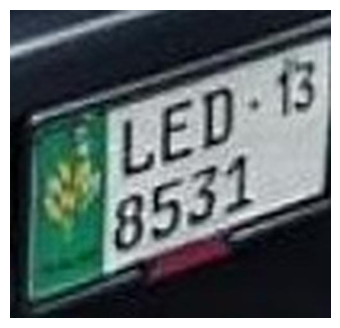

In [125]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("P-LPCD/PR-LPCD/images/train/lp_0001.jpg")

plt.figure(figsize=(12, 4))
plt.imshow(img)
plt.axis("off")
plt.show()

In [126]:
!find P-LPCD -type f | grep -Ei "yaml|yml|class|label|names"

Streaming output truncated to the last 5000 lines.
P-LPCD/P-LPCD/PS-LPCD/labels/train/lp_front_new_006222.txt
P-LPCD/P-LPCD/PS-LPCD/labels/train/lp_front_new_006223.txt
P-LPCD/P-LPCD/PS-LPCD/labels/train/lp_front_new_006224.txt
P-LPCD/P-LPCD/PS-LPCD/labels/train/lp_front_new_006225.txt
P-LPCD/P-LPCD/PS-LPCD/labels/train/lp_front_new_006226.txt
P-LPCD/P-LPCD/PS-LPCD/labels/train/lp_front_new_006227.txt
P-LPCD/P-LPCD/PS-LPCD/labels/train/lp_front_new_006229.txt
P-LPCD/P-LPCD/PS-LPCD/labels/train/lp_front_new_006230.txt
P-LPCD/P-LPCD/PS-LPCD/labels/train/lp_front_new_006231.txt
P-LPCD/P-LPCD/PS-LPCD/labels/train/lp_front_new_006235.txt
P-LPCD/P-LPCD/PS-LPCD/labels/train/lp_front_new_006236.txt
P-LPCD/P-LPCD/PS-LPCD/labels/train/lp_front_new_006237.txt
P-LPCD/P-LPCD/PS-LPCD/labels/train/lp_front_new_006238.txt
P-LPCD/P-LPCD/PS-LPCD/labels/train/lp_front_new_006240.txt
P-LPCD/P-LPCD/PS-LPCD/labels/train/lp_front_new_006241.txt
P-LPCD/P-LPCD/PS-LPCD/labels/train/lp_front_new_006243.txt
P-LPC

In [127]:
!cat P-LPCD/PR-LPCD/ReadMe.txt

In [128]:
!unzip -q /content/P-LPCD.zip -d /content/

replace /content/P-LPCD/dataset_info/class_instance_counts_PR-LPCD.xlsx? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [129]:
!find /content/P-LPCD/PR-LPCD/images -type f | wc -l
!find /content/P-LPCD/PR-LPCD/labels -type f | wc -l

650
650


In [130]:
!cat /content/P-LPCD/PR-LPCD/ReadMe.txt

In [131]:
!ls -lh /content/P-LPCD/PR-LPCD/ReadMe.txt

-rw-rw-rw- 1 root root 0 Sep 23  2025 /content/P-LPCD/PR-LPCD/ReadMe.txt


In [132]:
!find /content/P-LPCD -iname "ReadMe.txt" -exec ls -lh {} \;

-rw-rw-rw- 1 root root 0 Sep 23  2025 /content/P-LPCD/ReadMe.txt
-rw-rw-rw- 1 root root 1.8K Sep 23  2025 /content/P-LPCD/PS-LPCD/ReadMe.txt
-rw-r--r-- 1 root root 0 Sep 20 15:06 /content/P-LPCD/P-LPCD/ReadMe.txt
-rw-r--r-- 1 root root 1.8K Sep 20 15:06 /content/P-LPCD/P-LPCD/PS-LPCD/ReadMe.txt
-rw-r--r-- 1 root root 0 Sep 20 15:05 /content/P-LPCD/P-LPCD/PR-LPCD/ReadMe.txt
-rw-r--r-- 1 root root 0 Sep 20 15:05 /content/P-LPCD/P-LPCD/dataset_info/ReadMe.txt
-rw-rw-rw- 1 root root 0 Sep 23  2025 /content/P-LPCD/PR-LPCD/ReadMe.txt
-rw-rw-rw- 1 root root 0 Sep 23  2025 /content/P-LPCD/dataset_info/ReadMe.txt


In [133]:
!cat /content/P-LPCD/dataset_info/ReadMe.txt

In [134]:
import pandas as pd

file = "/content/P-LPCD/dataset_info/class_instance_counts_PR-LPCD.xlsx"

df = pd.read_excel(file)

display(df)

,Class_ID,Class_Name,Instances
0,0,A,231
1,1,B,93
2,2,C,77
3,3,D,32
4,4,E,583
5,5,F,48
6,6,G,8
7,7,H,22
8,8,I,4
9,9,J,5


In [135]:
import os

image_dir = "/content/P-LPCD/PR-LPCD/images/train"
label_dir = "/content/P-LPCD/PR-LPCD/labels/train"

image = sorted(os.listdir(image_dir))[0]
label = os.path.splitext(image)[0] + ".txt"

print("Image:", image)
print("Label:", label)

with open(os.path.join(label_dir, label)) as f:
    print(f.read())

Image: lp_0001.jpg
Label: lp_0001.txt
27 0.851150 0.265750 0.070740 0.170167
34 0.372360 0.694208 0.122520 0.239250
3 0.652520 0.343604 0.124040 0.229125
11 0.397950 0.430604 0.124540 0.244667
4 0.522430 0.393052 0.119140 0.233188
31 0.490400 0.651740 0.115840 0.231979
29 0.923580 0.244687 0.067360 0.166667
29 0.602470 0.605000 0.110660 0.227583
27 0.714960 0.564094 0.111000 0.226896



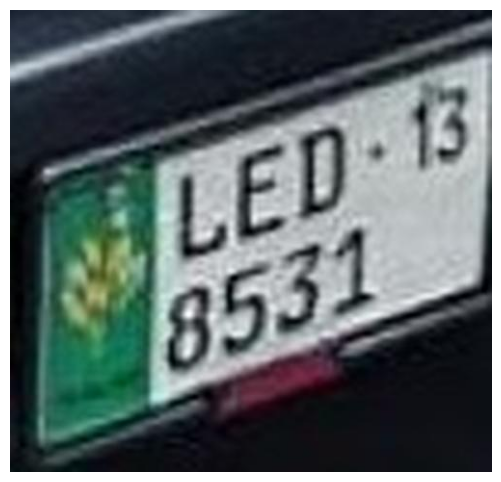

In [136]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/P-LPCD/PR-LPCD/images/train/lp_0001.jpg")

plt.figure(figsize=(12, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

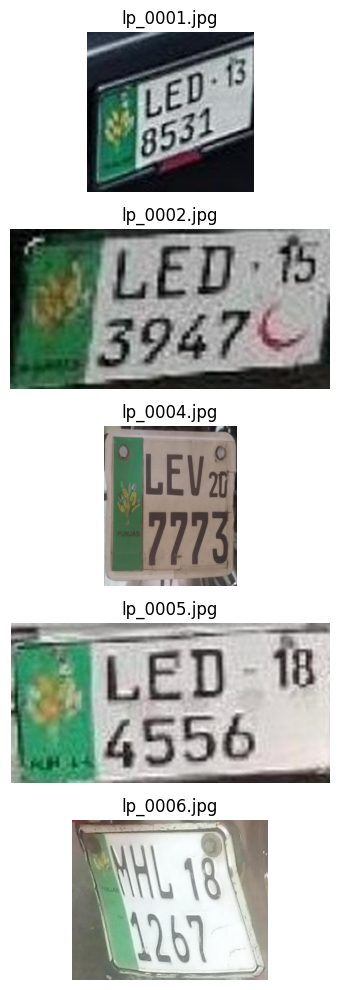

In [137]:
import os
from PIL import Image
import matplotlib.pyplot as plt

image_dir = "/content/P-LPCD/PR-LPCD/images/train"

images = sorted(os.listdir(image_dir))[:5]

fig, axes = plt.subplots(5, 1, figsize=(12, 10))

for ax, image in zip(axes, images):
    img = Image.open(os.path.join(image_dir, image))
    ax.imshow(img)
    ax.set_title(image)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [138]:
import os

label_dir = "/content/P-LPCD/PR-LPCD/labels"

for split in ["train", "val"]:
    files = os.listdir(os.path.join(label_dir, split))

    counts = []

    for file in files:
        with open(os.path.join(label_dir, split, file)) as f:
            counts.append(len(f.readlines()))

    print(split)
    print("Images:", len(files))
    print("Min characters:", min(counts))
    print("Max characters:", max(counts))
    print("Average:", sum(counts) / len(counts))

train
Images: 500
Min characters: 6
Max characters: 11
Average: 8.664
val
Images: 150
Min characters: 6
Max characters: 11
Average: 8.326666666666666


In [139]:
import os
import numpy as np

label_dir = "/content/P-LPCD/PR-LPCD/labels"

for split in ["train", "val"]:
    row_counts = []

    for file in os.listdir(os.path.join(label_dir, split)):
        ys = []

        with open(os.path.join(label_dir, split, file)) as f:
            for line in f:
                parts = line.split()
                ys.append(float(parts[2]))

        ys = sorted(ys)

        # Group characters based on vertical position
        rows = []

        for y in ys:
            placed = False

            for row in rows:
                if abs(y - np.mean(row)) < 0.15:
                    row.append(y)
                    placed = True
                    break

            if not placed:
                rows.append([y])

        row_counts.append(len(rows))

    print(split)
    print("1-row plates:", row_counts.count(1))
    print("2-row plates:", row_counts.count(2))
    print("3-row plates:", row_counts.count(3))

train
1-row plates: 0
2-row plates: 487
3-row plates: 13
val
1-row plates: 1
2-row plates: 147
3-row plates: 2


In [140]:
import os

label_dir = "/content/P-LPCD/PR-LPCD/labels"

count = 0

for split in ["train", "val"]:
    for file in os.listdir(os.path.join(label_dir, split)):
        path = os.path.join(label_dir, split, file)

        with open(path) as f:
            for line in f:
                if line.split()[0] == "36":
                    count += 1
                    break

print("Images containing PUNJAB:", count)

Images containing PUNJAB: 34


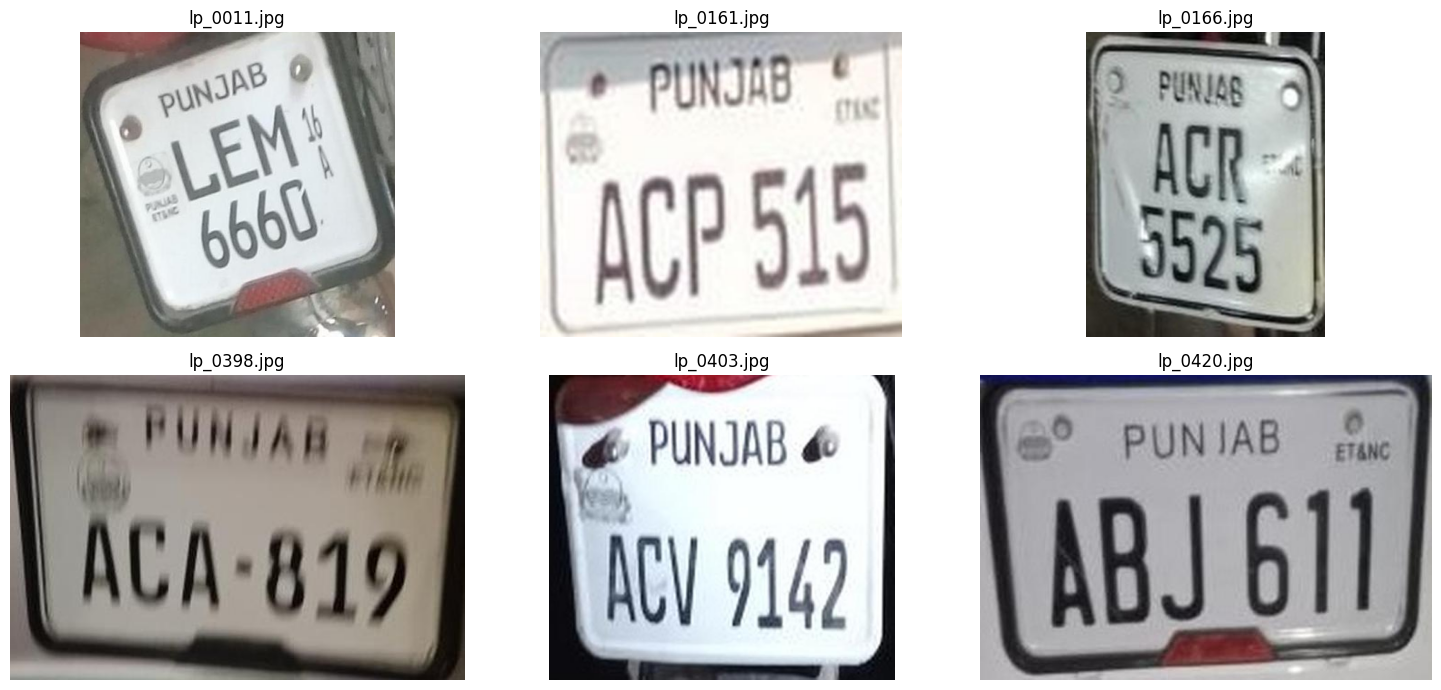

In [141]:
import os
import matplotlib.pyplot as plt
from PIL import Image

image_dir = "/content/P-LPCD/PR-LPCD/images/train"
label_dir = "/content/P-LPCD/PR-LPCD/labels/train"

samples = []

for file in sorted(os.listdir(label_dir)):
    path = os.path.join(label_dir, file)

    with open(path) as f:
        if any(line.split()[0] == "36" for line in f):
            samples.append(os.path.splitext(file)[0] + ".jpg")

    if len(samples) == 6:
        break

fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for ax, image in zip(axes.flat, samples):
    img = Image.open(os.path.join(image_dir, image))
    ax.imshow(img)
    ax.set_title(image)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [142]:
import os
import pandas as pd
import numpy as np

class_map = {
    0: "A", 1: "B", 2: "C", 3: "D", 4: "E", 5: "F",
    6: "G", 7: "H", 8: "I", 9: "J", 10: "K", 11: "L",
    12: "M", 13: "N", 14: "O", 15: "P", 16: "Q", 17: "R",
    18: "S", 19: "T", 20: "U", 21: "V", 22: "W", 23: "X",
    24: "Y", 25: "Z",
    26: "0", 27: "1", 28: "2", 29: "3",
    30: "4", 31: "5", 32: "6", 33: "7", 34: "8", 35: "9",
    36: "PUNJAB"
}

label_base = "/content/P-LPCD/PR-LPCD/labels"

records = []

for split in ["train", "val"]:
    label_dir = os.path.join(label_base, split)

    for file in sorted(os.listdir(label_dir)):
        if not file.endswith(".txt"):
            continue

        characters = []

        with open(os.path.join(label_dir, file)) as f:
            for line in f:
                parts = line.split()

                class_id = int(parts[0])
                x = float(parts[1])
                y = float(parts[2])

                characters.append({
                    "char": class_map[class_id],
                    "x": x,
                    "y": y
                })

        # Sort approximately by row first, then left-to-right
        characters.sort(key=lambda c: (c["y"], c["x"]))

        raw_layout = " ".join(c["char"] for c in characters)

        records.append({
            "split": split,
            "image": file.replace(".txt", ".jpg"),
            "num_chars": len(characters),
            "raw_layout": raw_layout
        })

df = pd.DataFrame(records)

print("Total records:", len(df))
display(df.head(20))

Total records: 650


,split,image,num_chars,raw_layout
0,train,lp_0001.jpg,9,3 1 D E L 1 3 5 8
1,train,lp_0002.jpg,9,5 1 D E L 7 4 9 3
2,train,lp_0004.jpg,9,L E V 2 0 3 7 7 7
3,train,lp_0005.jpg,9,8 1 D E L 6 5 5 4
4,train,lp_0006.jpg,9,M H L 8 1 1 2 6 7
5,train,lp_0008.jpg,9,E L E 1 3 7 9 5 8
6,train,lp_0009.jpg,9,L E C 1 5 3 5 3 3
7,train,lp_0010.jpg,9,9 1 E E L 9 2 6 6
8,train,lp_0011.jpg,11,PUNJAB 6 1 M E A L 0 6 6 6
9,train,lp_0012.jpg,9,8 1 H E L 1 5 2 8


In [143]:
pd.set_option("display.max_colwidth", None)

display(
    df["raw_layout"]
      .value_counts()
      .head(50)
      .to_frame("count")
)

,count
raw_layout,
L R 6 3 2 3,6
L E 2 0 2 4 7 1,6
5 1 E L 0 0 6 2,5
L E A 1 8 9 1 7 5 A,4
L E B 1 7 6 8 2 1 A,4
8 1 B E L 0 6 2,4
8 1 A E L 6 1 3 3,3
L E 1 5 6 9 8 3,3
L E E 1 4 6 2 1 2,3


In [144]:
print("Unique raw layouts:", df["raw_layout"].nunique())

Unique raw layouts: 553


In [145]:
!cat /content/P-LPCD/dataset_info/ReadMe.txt

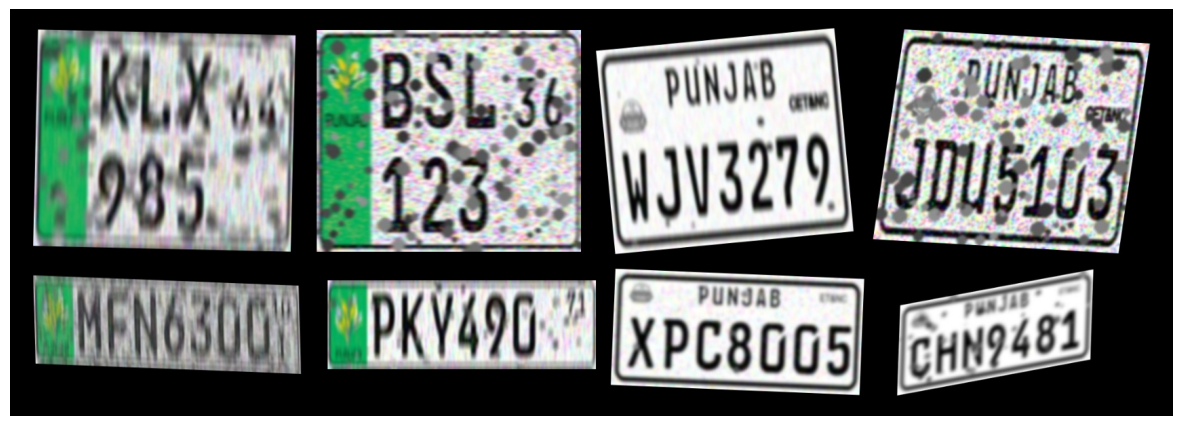

In [146]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/P-LPCD/dataset_info/lp_variations.png")

plt.figure(figsize=(15, 10))
plt.imshow(img)
plt.axis("off")
plt.show()

In [147]:
import re

def reorder_plate(raw):
    chars = raw.split()

    letters = [c for c in chars if c.isalpha() and c != "PUNJAB"]
    numbers = [c for c in chars if c.isdigit()]

    return "".join(letters + numbers)

df["reordered"] = df["raw_layout"].apply(reorder_plate)

display(df[["image", "raw_layout", "reordered"]].head(20))

,image,raw_layout,reordered
0,lp_0001.jpg,3 1 D E L 1 3 5 8,DEL311358
1,lp_0002.jpg,5 1 D E L 7 4 9 3,DEL517493
2,lp_0004.jpg,L E V 2 0 3 7 7 7,LEV203777
3,lp_0005.jpg,8 1 D E L 6 5 5 4,DEL816554
4,lp_0006.jpg,M H L 8 1 1 2 6 7,MHL811267
5,lp_0008.jpg,E L E 1 3 7 9 5 8,ELE137958
6,lp_0009.jpg,L E C 1 5 3 5 3 3,LEC153533
7,lp_0010.jpg,9 1 E E L 9 2 6 6,EEL919266
8,lp_0011.jpg,PUNJAB 6 1 M E A L 0 6 6 6,MEAL610666
9,lp_0012.jpg,8 1 H E L 1 5 2 8,HEL811528


In [148]:
label_path = "/content/P-LPCD/PR-LPCD/labels/train/lp_0001.txt"

class_map = {
    0:"A", 1:"B", 2:"C", 3:"D", 4:"E", 5:"F",
    6:"G", 7:"H", 8:"I", 9:"J", 10:"K", 11:"L",
    12:"M", 13:"N", 14:"O", 15:"P", 16:"Q", 17:"R",
    18:"S", 19:"T", 20:"U", 21:"V", 22:"W", 23:"X",
    24:"Y", 25:"Z",
    26:"0", 27:"1", 28:"2", 29:"3",
    30:"4", 31:"5", 32:"6", 33:"7", 34:"8", 35:"9",
    36:"PUNJAB"
}

chars = []

with open(label_path) as f:
    for line in f:
        parts = line.split()

        class_id = int(parts[0])
        x = float(parts[1])
        y = float(parts[2])

        chars.append({
            "char": class_map[class_id],
            "x": x,
            "y": y
        })

for c in sorted(chars, key=lambda c: c["x"]):
    print(c["char"], "x =", c["x"], "y =", c["y"])

8 x = 0.37236 y = 0.694208
L x = 0.39795 y = 0.430604
5 x = 0.4904 y = 0.65174
E x = 0.52243 y = 0.393052
3 x = 0.60247 y = 0.605
D x = 0.65252 y = 0.343604
1 x = 0.71496 y = 0.564094
1 x = 0.85115 y = 0.26575
3 x = 0.92358 y = 0.244687


In [149]:
import numpy as np
from sklearn.cluster import KMeans

# Use the chars list from the previous cell

X = np.array([[c["y"]] for c in chars])

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

rows = {}

for label, char in zip(labels, chars):
    rows.setdefault(label, []).append(char)

for row_id, row in sorted(rows.items(), key=lambda x: np.mean([c["y"] for c in x[1]])):
    row.sort(key=lambda c: c["x"])

    print(
        "Row:",
        "".join(c["char"] for c in row),
        "| y:",
        round(np.mean([c["y"] for c in row]), 3)
    )

Row: LED13 | y: 0.336
Row: 8531 | y: 0.629


In [150]:
import numpy as np

def get_plate_text(chars):
    if not chars:
        return ""

    # Remove PUNJAB from character ordering
    chars = [c for c in chars if c["char"] != "PUNJAB"]

    if not chars:
        return ""

    # Sort characters by Y coordinate
    chars_y = sorted(chars, key=lambda c: c["y"])

    y_values = np.array([c["y"] for c in chars_y])

    # Calculate gaps between consecutive Y coordinates
    gaps = np.diff(y_values)

    # Detect row breaks
    # A gap > 0.12 usually indicates a new row
    split_points = np.where(gaps > 0.12)[0]

    rows = []
    start = 0

    for point in split_points:
        rows.append(chars_y[start:point + 1])
        start = point + 1

    rows.append(chars_y[start:])

    # Sort rows top-to-bottom
    rows.sort(key=lambda row: np.mean([c["y"] for c in row]))

    # Sort characters inside each row left-to-right
    plate = ""

    for row in rows:
        row.sort(key=lambda c: c["x"])
        plate += "".join(c["char"] for c in row)

    return plate

In [151]:
plate = get_plate_text(chars)

print("Plate:", plate)

Plate: LED138531


In [152]:
records = []

for split in ["train", "val"]:
    label_dir = os.path.join(label_base, split)

    for file in sorted(os.listdir(label_dir)):
        if not file.endswith(".txt"):
            continue

        chars = []

        with open(os.path.join(label_dir, file)) as f:
            for line in f:
                parts = line.split()

                class_id = int(parts[0])
                x = float(parts[1])
                y = float(parts[2])

                chars.append({
                    "char": class_map[class_id],
                    "x": x,
                    "y": y
                })

        plate_text = get_plate_text(chars)

        records.append({
            "split": split,
            "image": file.replace(".txt", ".jpg"),
            "plate_text": plate_text,
            "num_chars": len(chars)
        })

df = pd.DataFrame(records)

display(df.head(20))

,split,image,plate_text,num_chars
0,train,lp_0001.jpg,LED138531,9
1,train,lp_0002.jpg,LED153947,9
2,train,lp_0004.jpg,LEV207773,9
3,train,lp_0005.jpg,LED184556,9
4,train,lp_0006.jpg,MHL181267,9
5,train,lp_0008.jpg,LEE135897,9
6,train,lp_0009.jpg,LEC153533,9
7,train,lp_0010.jpg,6L6E2E919,9
8,train,lp_0011.jpg,LEM16A6660,11
9,train,lp_0012.jpg,LEH188251,9


In [153]:
import re

def is_valid_extracted(text):
    return bool(re.fullmatch(r"[A-Z0-9]+", text))

df["valid_chars"] = df["plate_text"].apply(is_valid_extracted)

print("Valid:", df["valid_chars"].sum())
print("Invalid:", (~df["valid_chars"]).sum())

Valid: 650
Invalid: 0


In [154]:
print(df["plate_text"].str.len().value_counts().sort_index())

plate_text
6      46
7      81
8     112
9     303
10    107
11      1
Name: count, dtype: int64


In [155]:
def starts_with_digit(text):
    return text[0].isdigit() if text else False

df["starts_with_digit"] = df["plate_text"].apply(starts_with_digit)

display(
    df[df["starts_with_digit"]][
        ["image", "plate_text", "num_chars"]
    ].head(30)
)

,image,plate_text,num_chars
7,lp_0010.jpg,6L6E2E919,9
54,lp_0070.jpg,5L8E4C712,9
60,lp_0078.jpg,3L7E9614,8
69,lp_0088.jpg,9L1E7A51A8,10
73,lp_0094.jpg,6L8E2B11A7,10
75,lp_0096.jpg,6L8E2B11A7,10
80,lp_0101.jpg,1L7E2B618,9
86,lp_0109.jpg,1L1E9C412,9
108,lp_0135.jpg,2L6E0015,8
113,lp_0142.jpg,1L3E2614,8


In [156]:
affected = df["starts_with_digit"].sum()
total = len(df)
percentage = (affected / total) * 100

print("Rows affected:", affected)
print("Total rows:", total)
print("Percentage:", round(percentage, 2), "%")

Rows affected: 36
Total rows: 650
Percentage: 5.54 %


**NEWWWWWWWWWWWW
**

In [157]:
import os

ps_base = "/content/P-LPCD/PS-LPCD"

for split in ["train", "val"]:
    image_dir = os.path.join(ps_base, "images", split)
    label_dir = os.path.join(ps_base, "labels", split)

    print(split)
    print("Images:", len(os.listdir(image_dir)))
    print("Labels:", len(os.listdir(label_dir)))
    print()

train
Images: 32000
Labels: 32000

val
Images: 8000
Labels: 8000



In [160]:
records = []

for split in ["train", "val"]:
    label_dir = os.path.join(ps_base, "labels", split)

    for file in sorted(os.listdir(label_dir)):
        if not file.endswith(".txt"):
            continue

        chars = []

        with open(os.path.join(label_dir, file)) as f:
            for line in f:
                parts = line.split()

                class_id = int(float(parts[0]))
                x = float(parts[1])
                y = float(parts[2])

                chars.append({
                    "char": class_map[class_id],
                    "x": x,
                    "y": y
                })

        plate_text = get_plate_text(chars)

        records.append({
            "split": split,
            "image": file.replace(".txt", ".jpg"),
            "plate_text": plate_text,
            "num_chars": len(chars)
        })

ps_df = pd.DataFrame(records)

print("Total records:", len(ps_df))
display(ps_df.head(20))

Total records: 40000


,split,image,plate_text,num_chars
0,train,lp_back_000001.jpg,MVD75675J,9
1,train,lp_back_000002.jpg,BHA060126W,10
2,train,lp_back_000003.jpg,NAD49764,8
3,train,lp_back_000004.jpg,WFW40887T,9
4,train,lp_back_000005.jpg,AHL304707Z,10
5,train,lp_back_000006.jpg,JGW78125B,9
6,train,lp_back_000007.jpg,HEW51205F,9
7,train,lp_back_000008.jpg,MLG432188I,10
8,train,lp_back_000010.jpg,MEX22056,8
9,train,lp_back_000011.jpg,KZI523587Y,10


In [161]:
ps_df["starts_with_digit"] = ps_df["plate_text"].str.match(r"^\d")

affected = ps_df["starts_with_digit"].sum()
percentage = affected / len(ps_df) * 100

print("Rows starting with digit:", affected)
print("Percentage:", round(percentage, 2), "%")

Rows starting with digit: 8142
Percentage: 20.36 %


In [162]:
print(ps_df["plate_text"].str.len().value_counts().sort_index())

plate_text
6      9980
7     10020
8      4939
9     10113
10     4948
Name: count, dtype: int64


In [163]:
display(
    ps_df[ps_df["starts_with_digit"]][
        ["image", "plate_text", "num_chars"]
    ].head(30)
)

,image,plate_text,num_chars
15993,lp_front_000001.jpg,72FHS7743,9
15994,lp_front_000002.jpg,96BPU5614,9
15995,lp_front_000003.jpg,82EEX208,8
15996,lp_front_000004.jpg,69GAS2320,9
15997,lp_front_000005.jpg,60PLW081,8
15998,lp_front_000006.jpg,65JBP839,8
15999,lp_front_000008.jpg,78LIQ635E,9
16002,lp_front_000013.jpg,83DGJ0131V,10
16003,lp_front_000014.jpg,05HBK4372E,10
16005,lp_front_000016.jpg,44JQX784,8


In [164]:
pattern_6 = ps_df["plate_text"].str.fullmatch(r"[A-Z]{3}\d{3}")
pattern_7 = ps_df["plate_text"].str.fullmatch(r"[A-Z]{3}\d{4}")

valid = pattern_6 | pattern_7

print("ABC123:", pattern_6.sum())
print("ABC1234:", pattern_7.sum())
print("Total matching:", valid.sum())
print("Percentage:", round(valid.mean() * 100, 2), "%")

ABC123: 9980
ABC1234: 10020
Total matching: 20000
Percentage: 50.0 %


In [165]:
patterns = {
    "ABC123": r"[A-Z]{3}\d{3}",
    "ABC1234": r"[A-Z]{3}\d{4}",
    "ABC12345": r"[A-Z]{3}\d{5}",
    "AB123": r"[A-Z]{2}\d{3}",
    "AB1234": r"[A-Z]{2}\d{4}",
    "AB123456": r"[A-Z]{2}\d{6}"
}

for name, pattern in patterns.items():
    count = ps_df["plate_text"].str.fullmatch(pattern).sum()
    print(f"{name}: {count}")

ABC123: 9980
ABC1234: 10020
ABC12345: 2913
AB123: 0
AB1234: 0
AB123456: 0


In [166]:
pattern_1 = ps_df["plate_text"].str.fullmatch(r"[A-Z]{3}\d{3}")
pattern_2 = ps_df["plate_text"].str.fullmatch(r"[A-Z]{3}\d{4}")
pattern_3 = ps_df["plate_text"].str.fullmatch(r"[A-Z]{3}\d{5}")
pattern_4 = ps_df["plate_text"].str.fullmatch(r"[A-Z]{3}\d{6}")

print("ABC123:", pattern_1.sum())
print("ABC1234:", pattern_2.sum())
print("ABC12345:", pattern_3.sum())
print("ABC123456:", pattern_4.sum())

valid = pattern_1 | pattern_2 | pattern_3 | pattern_4

print("\nTotal matching:", valid.sum())
print("Percentage:", round(valid.mean() * 100, 2), "%")

ABC123: 9980
ABC1234: 10020
ABC12345: 2913
ABC123456: 2893

Total matching: 25806
Percentage: 64.52 %


In [167]:
target_mask = (
    ps_df["plate_text"].str.fullmatch(r"[A-Z]{3}\d{3}") |
    ps_df["plate_text"].str.fullmatch(r"[A-Z]{3}\d{4}") |
    ps_df["plate_text"].str.fullmatch(r"[A-Z]{3}\d{5}") |
    ps_df["plate_text"].str.fullmatch(r"[A-Z]{3}\d{6}")
)

target_df = ps_df[target_mask].copy()

print("Target records:", len(target_df))
print("Removed:", len(ps_df) - len(target_df))
print("Remaining percentage:", round(len(target_df) / len(ps_df) * 100, 2), "%")

Target records: 25806
Removed: 14194
Remaining percentage: 64.52 %


In [168]:
import re

def get_format(text):
    if re.fullmatch(r"[A-Z]{3}\d{3}", text):
        return "ABC123"
    elif re.fullmatch(r"[A-Z]{3}\d{4}", text):
        return "ABC1234"
    elif re.fullmatch(r"[A-Z]{3}\d{5}", text):
        return "ABC12345"
    elif re.fullmatch(r"[A-Z]{3}\d{6}", text):
        return "ABC123456"

target_df["format"] = target_df["plate_text"].apply(get_format)

print(target_df["format"].value_counts())

format
ABC1234      10020
ABC123        9980
ABC12345      2913
ABC123456     2893
Name: count, dtype: int64


In [169]:
for fmt in ["ABC123", "ABC1234", "ABC12345", "ABC123456"]:
    print(f"\n--- {fmt} ---")
    display(
        target_df[target_df["format"] == fmt][
            ["image", "plate_text"]
        ].head(10)
    )


--- ABC123 ---


,image,plate_text
8002,lp_back_new_000002.jpg,MLS632
8004,lp_back_new_000006.jpg,MGT203
8005,lp_back_new_000007.jpg,NWV924
8009,lp_back_new_000013.jpg,DZT889
8012,lp_back_new_000017.jpg,IFW460
8016,lp_back_new_000021.jpg,ZYD157
8017,lp_back_new_000022.jpg,DHF074
8019,lp_back_new_000024.jpg,YFZ374
8024,lp_back_new_000029.jpg,XCV792
8025,lp_back_new_000031.jpg,UOK512



--- ABC1234 ---


,image,plate_text
8001,lp_back_new_000001.jpg,HVC9795
8003,lp_back_new_000005.jpg,VYH8705
8006,lp_back_new_000008.jpg,YPX0507
8007,lp_back_new_000011.jpg,HNI1776
8008,lp_back_new_000012.jpg,IVI5971
8010,lp_back_new_000014.jpg,WTH8281
8011,lp_back_new_000016.jpg,VHN2917
8013,lp_back_new_000018.jpg,EQJ2114
8014,lp_back_new_000019.jpg,JPA9744
8015,lp_back_new_000020.jpg,QUE0121



--- ABC12345 ---


,image,plate_text
2,lp_back_000003.jpg,NAD49764
8,lp_back_000010.jpg,MEX22056
10,lp_back_000012.jpg,OZL51833
11,lp_back_000013.jpg,DNI93194
12,lp_back_000014.jpg,PIS36105
18,lp_back_000021.jpg,MRX62851
25,lp_back_000032.jpg,OHG60575
28,lp_back_000035.jpg,VAV14320
30,lp_back_000037.jpg,GPM58749
31,lp_back_000038.jpg,GVP07045



--- ABC123456 ---


,image,plate_text
14,lp_back_000016.jpg,TAF002769
17,lp_back_000020.jpg,PGA227214
23,lp_back_000029.jpg,YTY369367
26,lp_back_000033.jpg,WRW346238
27,lp_back_000034.jpg,HCZ962346
29,lp_back_000036.jpg,CNO816549
34,lp_back_000041.jpg,EVG706304
36,lp_back_000043.jpg,FST357912
39,lp_back_000046.jpg,RKJ380312
48,lp_back_000058.jpg,IAK685782


In [170]:
target_df.to_csv(
    "/content/ps_lpcd_target_plates.csv",
    index=True
)

print("Saved:", "/content/ps_lpcd_target_plates.csv")
print("Rows:", len(target_df))

Saved: /content/ps_lpcd_target_plates.csv
Rows: 25806


In [171]:
check_df = pd.read_csv("/content/ps_lpcd_target_plates.csv")

print("Rows:", len(check_df))
display(check_df.head())

Rows: 25806


,Unnamed: 0,split,image,plate_text,num_chars,starts_with_digit,format
0,2,train,lp_back_000003.jpg,NAD49764,8,False,ABC12345
1,8,train,lp_back_000010.jpg,MEX22056,8,False,ABC12345
2,10,train,lp_back_000012.jpg,OZL51833,8,False,ABC12345
3,11,train,lp_back_000013.jpg,DNI93194,8,False,ABC12345
4,12,train,lp_back_000014.jpg,PIS36105,8,False,ABC12345


# **Implementing N Gram**

**Load Data**

In [172]:
import pandas as pd

df = pd.read_csv("/content/ps_lpcd_target_plates.csv")

print("Total plates:", len(df))
display(df.head())

Total plates: 25806


,Unnamed: 0,split,image,plate_text,num_chars,starts_with_digit,format
0,2,train,lp_back_000003.jpg,NAD49764,8,False,ABC12345
1,8,train,lp_back_000010.jpg,MEX22056,8,False,ABC12345
2,10,train,lp_back_000012.jpg,OZL51833,8,False,ABC12345
3,11,train,lp_back_000013.jpg,DNI93194,8,False,ABC12345
4,12,train,lp_back_000014.jpg,PIS36105,8,False,ABC12345


In [210]:
plates = df["plate_text"].astype(str).str.upper().tolist()
existing_plates = set(plates)
print("Total plates:", len(plates))
print("Examples:")
print(plates[:10])

Total plates: 25806
Examples:
['NAD49764', 'MEX22056', 'OZL51833', 'DNI93194', 'PIS36105', 'TAF002769', 'PGA227214', 'MRX62851', 'YTY369367', 'OHG60575']


In [211]:
corpus = ["^" + plate + "$" for plate in plates]

print(corpus[:10])

['^NAD49764$', '^MEX22056$', '^OZL51833$', '^DNI93194$', '^PIS36105$', '^TAF002769$', '^PGA227214$', '^MRX62851$', '^YTY369367$', '^OHG60575$']


In [212]:
from collections import Counter, defaultdict
import math

ngram_counts = {
    1: defaultdict(Counter),
    2: defaultdict(Counter),
    3: defaultdict(Counter),
    4: defaultdict(Counter)
}

for plate in corpus:
    for n in range(1, 5):
        for i in range(len(plate) - n):
            context = plate[i:i+n]
            next_char = plate[i+n]
            ngram_counts[n][context][next_char] += 1

In [224]:
def get_probability(context, char, n, alpha=0.1):
    counts = ngram_counts[n].get(context, {})

    total = sum(counts.values())
    vocab = 36

    count = counts.get(char, 0)

    return (count + alpha) / (total + alpha * vocab)


def next_char_probability(context, char):
    context = context.upper()

    probabilities = []

    for n in [1, 2, 3, 4]:
        if len(context) >= n:
            ctx = context[-n:]
            probabilities.append(
                get_probability(ctx, char, n)
            )

    weights = [0.1, 0.2, 0.3, 0.4]

    weights = weights[-len(probabilities):]

    total_weight = sum(weights)

    return sum(
        p * w
        for p, w in zip(probabilities, weights)
    ) / total_weight

In [225]:
formats = {
    "ABC123": "LLLDDD",
    "ABC1234": "LLLDDDD",
    "ABC12345": "LLLDDDDD",
    "ABC123456": "LLLDDDDDD"
}

In [226]:
import string

LETTERS = string.ascii_uppercase
DIGITS = string.digits

In [227]:
def generate_plates(prefix="", format_name=None, top_k=10, beam_width=100):
    prefix = prefix.upper()

    target_formats = (
        [formats[format_name]]
        if format_name
        else list(formats.values())
    )

    candidates = []

    for fmt in target_formats:
        target_length = len(fmt)

        if len(prefix) > target_length:
            continue

        valid = True

        for i, char in enumerate(prefix):
            if fmt[i] == "L" and char not in LETTERS:
                valid = False
                break

            if fmt[i] == "D" and char not in DIGITS:
                valid = False
                break

        if not valid:
            continue

        beam = [(prefix, 0.0)]

        while beam and len(beam[0][0]) < target_length:
            new_beam = []

            for current, score in beam:
                position = len(current)

                allowed = (
                    LETTERS
                    if fmt[position] == "L"
                    else DIGITS
                )

                for char in allowed:
                    probability = next_char_probability(
                        "^" + current,
                        char
                    )

                    new_score = score + math.log(probability)

                    new_beam.append(
                        (current + char, new_score)
                    )

            new_beam.sort(key=lambda x: x[1], reverse=True)

            beam = new_beam[:beam_width]

        candidates.extend(beam)

    candidates.sort(key=lambda x: x[1], reverse=True)

    new_candidates = [
        (plate, score)
        for plate, score in candidates
        if plate not in existing_plates
    ]

    return new_candidates[:top_k]

In [237]:
def format_plate(plate):
    plate = plate.upper()

    if len(plate) == 6:
        return plate[:3] + " " + plate[3:]
    elif len(plate) == 7:
        return plate[:3] + " " + plate[3:]
    elif len(plate) == 8:
        return plate[:3] + " " + plate[3:5] + " " + plate[5:]
    elif len(plate) == 9:
        return plate[:3] + " " + plate[3:5] + " " + plate[5:]

    return plate

In [242]:
recommendations = generate_plates("ABC", top_k=20)

for plate, score in recommendations:
    print(f"{format_plate(plate)}  Score: {score:.6f}")

ABC 795  Score: -5.654437
ABC 771  Score: -5.985549
ABC 769  Score: -5.997719
ABC 765  Score: -6.327219
ABC 766  Score: -6.330875
ABC 768  Score: -6.332769
ABC 763  Score: -6.379244
ABC 760  Score: -6.379772
ABC 773  Score: -6.666703
ABC 796  Score: -6.781251
ABC 791  Score: -6.800554
ABC 762  Score: -6.904126
ABC 761  Score: -6.927854
ABC 767  Score: -6.952960
ABC 778  Score: -7.049254
ABC 770  Score: -7.049945
ABC 779  Score: -7.094003
ABC 798  Score: -7.095936
ABC 775  Score: -7.096415
ABC 793  Score: -7.100054


In [245]:
recommendations=generate_plates(
    prefix="ABC",
    format_name="ABC12345",
    top_k=10
)
for plate, score in recommendations:
    print(f"{format_plate(plate)}   Score: {score:.6f}")

ABC 77 133   Score: -10.129591
ABC 77 102   Score: -10.223289
ABC 76 448   Score: -10.224261
ABC 79 554   Score: -10.252416
ABC 77 107   Score: -10.279214
ABC 79 500   Score: -10.370654
ABC 79 503   Score: -10.395801
ABC 79 559   Score: -10.421275
ABC 79 553   Score: -10.506174
ABC 77 333   Score: -10.523391
